# Installation Instructions 𐔌՞ ܸ.ˬ.ܸ՞𐦯


# Qwen Benchmark: 
### Full vs Q4_K_M vs Q2_K

Compares three versions of Qwen2-7B on llama.cpp across:
- **Speed** — tokens per second
- **Latency** — time to first token + total time
- **Memory** — RAM/VRAM usage
- **Quality** — response on identical prompts

| Model | Bits | Expected Size | Expected Speed |
|---|---|---|---|
| Qwen2-7B (full) | 16-bit | ~14GB | Slowest |
| Qwen2-7B Q4_K_M | 4-bit | ~4.5GB | Fast   |
| Qwen2-7B Q2_K | 2-bit | ~2.5GB | Fastest   |


### Convert Qwen to GGUF
GGUF (GPT-Generated Unified Format) is a binary file format designed to store and run large language models (LLMs) efficiently, especially on consumer-grade hardware. It was developed by Georgi Gerganov, the creator of the popular llama.cpp inference framework. 

Key Features and Benefits
- Efficiency: GGUF is optimized for quick loading and saving of models. It uses memory mapping (mmap), which allows the operating system to load only the parts of the model currently needed, - making it possible to run models larger than your available RAM.
- Single-File Deployment: Unlike other formats that require separate configuration, tokenizer, and weight files, a GGUF file is self-contained. It encapsulates everything—model weights, metadata, and prompt templates—into one file.
- CPU & GPU Support: GGUF can run entirely on a CPU or be partially/fully offloaded to a GPU to speed up performance.
- Quantization: It supports various levels of quantization (shrinking the model size), typically ranging from 2-bit to 8-bit precision. This reduces model size by 50-75% without massive quality loss, enabling complex AI to run on laptops or smartphones. 

```
Q  4  _K_M
│  │   │ │
│  │   │ └── M = Medium (balanced within the K family)
│  │   └──── K = K-quant method (smarter than basic Q4)
│  └──────── 4 = 4 bits per weight
└─────────── Q = Quantized
``` 

---

# AIM: Understand Model Quantization (●´ω｀●)

why not use Nunchaku?


# llama.cpp / GGUF vs Nunchaku / SVDQuant

| | **llama.cpp / GGUF** | **Nunchaku / SVDQuant** |
|---|---|---|
| Target models | LLMs (Qwen, Llama, etc.) | **Diffusion models** (FLUX, SANA, etc.) |
| Quantization | Q4_K_M, Q2_K (GGUF format) | INT4/NVFP4 via SVDQuant |
| Use case | Text generation | Image generation |
| Install | Build from source | `pip install nunchaku` |

> **Note:** Nunchaku is a high-performance inference engine for 4-bit diffusion models, implementing SVDQuant — it targets image generation models like FLUX.1, not language models like Qwen.


## Step 1: Check What's in Build
```bash
ls build/
```

---

## Step 2: Compile llama.cpp (pick your hardware)

### Apple Silicon — M1/M2/M3/M4 ✅ (recommended if on Mac)
```bash
cmake -B build -DGGML_METAL=ON
cmake --build build --config Release -j$(nproc)
```

### NVIDIA GPU (CUDA)
```bash
cmake -B build -DGGML_CUDA=ON
cmake --build build --config Release -j$(nproc)
```

### CPU Only
```bash
cmake -B build
cmake --build build --config Release -j$(nproc)
```

> `-j$(nproc)` uses all available CPU cores to speed up compilation.
> Takes roughly 1–3 minutes depending on your machine.


---
## Step 1: Prepare the Models


| | **Qwen3.6-35B-A3B** | **Qwen3-8B** |
|---|---|---|
| F16 | ~70GB | ~16GB |
| Q4_K_M | ~22GB | ~5GB |
| Q2_K | ~12GB | ~3GB |

# Qwen3.6-35B-A3B
If you haven't already converted and quantized Qwen, run these shell commands first.

```bash
# Download Qwen from HuggingFace
hf download Qwen/Qwen3.6-35B-A3B --local-dir ./llama.cpp/models/qwen3.6-35b
# Convert to GGUF (full 16-bit)
cd llama.cpp
pip install -r requirements.txt
python convert_hf_to_gguf.py models/qwen3.6-35b --outfile ../qwen3.6-35b-f16.gguf


# Quantize to Q4_K_M (~4.5GB)
./build/bin/llama-quantize ../qwen3.6-35b-f16.gguf ../qwen3.6-35b-q4km.gguf Q4_K_M

# Quantize to Q2_K (~2.5GB)
./build/bin/llama-quantize ../qwen3.6-35b-f16.gguf ../qwen3.6-35b-q2k.gguf Q2_K
```

After this you should have 3 files:
```
qwen3.6-35b-f16.gguf    (~70GB)
qwen3.6-35b-q4km.gguf   (~22GB)
qwen3.6-35b-q2k.gguf    (~12GB)
```

# Qwen3-8B

## Step 1: Prepare the Models

If you haven't already converted and quantized Qwen, run these shell commands first.

```bash
# Download Qwen from HuggingFace
hf download Qwen/Qwen3-8B --local-dir ./llama.cpp/models/qwen3-8b

# Convert to GGUF (full 16-bit)
cd llama.cpp
pip install -r requirements.txt
python convert_hf_to_gguf.py models/qwen3-8b --outfile ../qwen3-8b-f16.gguf

# Quantize to Q4_K_M (~5GB)
./build/bin/llama-quantize ../qwen3-8b-f16.gguf ../qwen3-8b-q4km.gguf Q4_K_M

# Quantize to Q2_K (~3GB)
./build/bin/llama-quantize ../qwen3-8b-f16.gguf ../qwen3-8b-q2k.gguf Q2_K
```

After this you should have 3 files:
```
qwen3-8b-f16.gguf    (~16GB)
qwen3-8b-q4km.gguf   (~5GB)
qwen3-8b-q2k.gguf    (~3GB)
```



---
## Step 2: Configure Paths & Prompts

In [2]:
import os

# ── Edit these paths to match your files ──────────────────────────
MODELS = {
    # "Full F16":  "./qwen3-8b-f16.gguf",
    "Q4_K_M":    "./qwen3-8b-q4km.gguf",
    "Q2_K":      "./qwen3-8b-q2k.gguf",
}

N_GPU_LAYERS = 35    # GPU layers to offload (0 = CPU only)
N_CTX        = 2048  # context window
MAX_TOKENS   = 200   # tokens to generate per prompt
TEMPERATURE  = 0.1   # low = deterministic (better for fair comparison)
# ──────────────────────────────────────────────────────────────────

# Benchmark prompts — mix of short, medium, and reasoning tasks
PROMPTS = [
    "What is the capital of France?",
    "Explain how retrieval augmented generation works in 3 sentences.",
    "Write a Python function that reverses a linked list.",
    "Compare transformer attention mechanisms to RNNs. Be concise.",
    "What are the pros and cons of 4-bit quantization for LLMs?"
]

# Check files exist
for name, path in MODELS.items():
    status = "✅" if os.path.exists(path) else "❌ NOT FOUND"
    size   = f"{os.path.getsize(path) / 1e9:.1f}GB" if os.path.exists(path) else "—"
    print(f"  {status} {name}: {path} ({size})")

  ✅ Q4_K_M: ./qwen3-8b-q4km.gguf (5.0GB)
  ✅ Q2_K: ./qwen3-8b-q2k.gguf (3.3GB)


---
## Step 3: Run the Benchmark

In [3]:
# !pip install llama-cpp-python


In [4]:
# check RAM
import psutil
ram = psutil.virtual_memory()
print(f"Total : {ram.total / 1e9:.1f} GB")
print(f"Free  : {ram.available / 1e9:.1f} GB")

Total : 17.2 GB
Free  : 5.8 GB


In [5]:
import time
import psutil
import os
from llama_cpp import Llama

results = {}   # model_name → list of per-prompt result dicts

def get_ram_gb():
    """Current process RAM usage in GB."""
    proc = psutil.Process(os.getpid())
    return proc.memory_info().rss / 1e9

for model_name, model_path in MODELS.items():

    if not os.path.exists(model_path):
        print(f"⚠️  Skipping {model_name} — file not found")
        continue

    print(f"\n{'='*55}")
    print(f"  Loading: {model_name}")
    print(f"{'='*55}")

    ram_before = get_ram_gb()
    load_start = time.perf_counter()

    llm = Llama(
        model_path=model_path,
        n_ctx=N_CTX,
        n_gpu_layers=N_GPU_LAYERS,
        verbose=False
    )

    load_time = time.perf_counter() - load_start
    ram_after  = get_ram_gb()
    ram_used   = ram_after - ram_before

    print(f"  Load time : {load_time:.1f}s")
    print(f"  RAM used  : {ram_used:.2f} GB")

    model_results = []

    for i, prompt in enumerate(PROMPTS):
        print(f"\n  Prompt {i+1}/{len(PROMPTS)}: {prompt[:50]}...")

        t0 = time.perf_counter()
        output = llm(
            prompt,
            max_tokens=MAX_TOKENS,
            temperature=TEMPERATURE,
            echo=False
        )
        elapsed = time.perf_counter() - t0

        response_text   = output["choices"][0]["text"].strip()
        tokens_generated = output["usage"]["completion_tokens"]
        tokens_per_sec   = tokens_generated / elapsed if elapsed > 0 else 0

        model_results.append({
            "prompt":          prompt,
            "response":        response_text,
            "tokens_generated": tokens_generated,
            "elapsed_sec":     round(elapsed, 2),
            "tokens_per_sec":  round(tokens_per_sec, 1),
            "ram_gb":          round(ram_used, 2),
            "load_time_sec":   round(load_time, 1)
        })

        print(f"    {tokens_per_sec:.1f} tok/s | {elapsed:.1f}s | {tokens_generated} tokens")

    results[model_name] = model_results

    # Free memory before loading next model
    del llm
    import gc; gc.collect()

print("\n✅ Benchmark complete")


  Loading: Q4_K_M


llama_context: n_ctx_seq (2048) < n_ctx_train (40960) -- the full capacity of the model will not be utilized


  Load time : 0.9s
  RAM used  : 0.89 GB

  Prompt 1/5: What is the capital of France?...
    10.0 tok/s | 20.0s | 200 tokens

  Prompt 2/5: Explain how retrieval augmented generation works i...
    16.0 tok/s | 12.5s | 200 tokens

  Prompt 3/5: Write a Python function that reverses a linked lis...
    15.0 tok/s | 13.4s | 200 tokens

  Prompt 4/5: Compare transformer attention mechanisms to RNNs. ...
    14.9 tok/s | 13.4s | 200 tokens

  Prompt 5/5: What are the pros and cons of 4-bit quantization f...


llama_context: n_ctx_seq (2048) < n_ctx_train (40960) -- the full capacity of the model will not be utilized


    15.4 tok/s | 12.9s | 200 tokens

  Loading: Q2_K
  Load time : 0.2s
  RAM used  : 0.36 GB

  Prompt 1/5: What is the capital of France?...
    12.7 tok/s | 15.8s | 200 tokens

  Prompt 2/5: Explain how retrieval augmented generation works i...
    16.4 tok/s | 12.2s | 200 tokens

  Prompt 3/5: Write a Python function that reverses a linked lis...
    16.7 tok/s | 12.0s | 200 tokens

  Prompt 4/5: Compare transformer attention mechanisms to RNNs. ...
    16.4 tok/s | 12.2s | 200 tokens

  Prompt 5/5: What are the pros and cons of 4-bit quantization f...
    15.8 tok/s | 12.6s | 200 tokens

✅ Benchmark complete


---
## Step 4: Results Table

In [6]:
import statistics

print(f"{'Model':<12} {'Avg tok/s':>10} {'Avg time(s)':>12} {'RAM (GB)':>10} {'Load (s)':>10}")
print("-" * 58)

summary = {}
for model_name, runs in results.items():
    avg_tps    = statistics.mean(r["tokens_per_sec"]  for r in runs)
    avg_time   = statistics.mean(r["elapsed_sec"]     for r in runs)
    ram        = runs[0]["ram_gb"]
    load_time  = runs[0]["load_time_sec"]
    summary[model_name] = {"avg_tps": avg_tps, "avg_time": avg_time, "ram": ram, "load": load_time}
    print(f"{model_name:<12} {avg_tps:>10.1f} {avg_time:>12.2f} {ram:>10.2f} {load_time:>10.1f}")

# Speedup relative to full model
if "Full F16" in summary and summary["Full F16"]["avg_tps"] > 0:
    base = summary["Full F16"]["avg_tps"]
    print("\nSpeedup vs Full F16:")
    for name, s in summary.items():
        speedup = s["avg_tps"] / base
        print(f"  {name:<12} {speedup:.2f}x")

Model         Avg tok/s  Avg time(s)   RAM (GB)   Load (s)
----------------------------------------------------------
Q4_K_M             14.3        14.45       0.89        0.9
Q2_K               15.6        12.95       0.36        0.2


---
## Step 5: Speed & Memory Charts

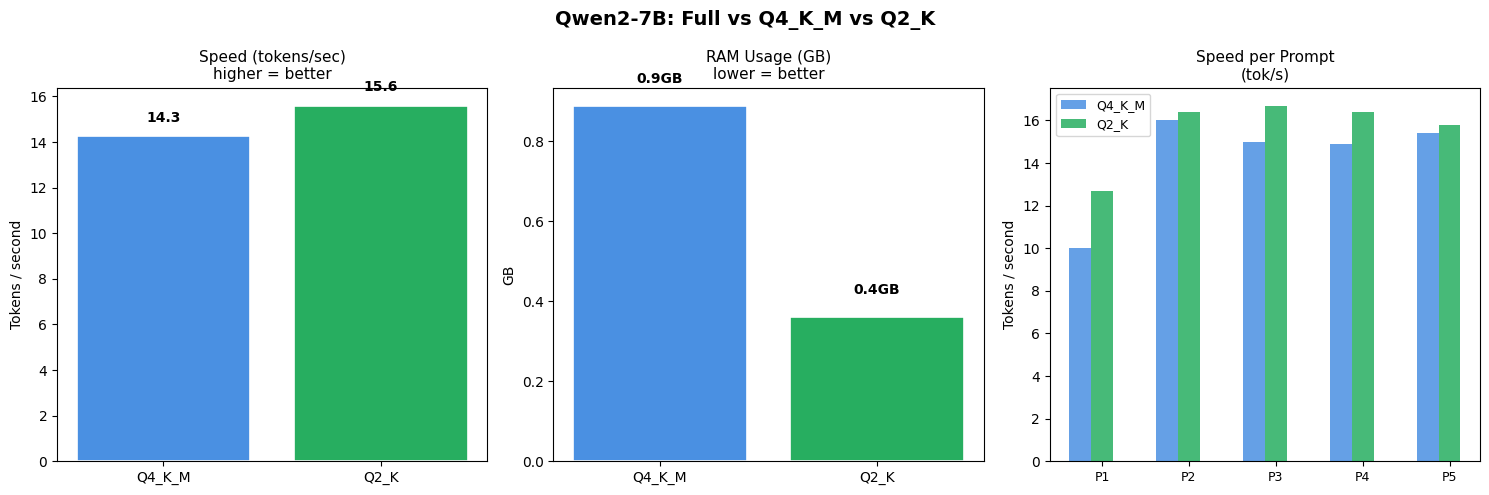

✅ Chart saved as qwen_benchmark.png


In [7]:
import matplotlib.pyplot as plt
import numpy as np

model_names = list(results.keys())
colors = ["#4A90E2", "#27AE60", "#E74C3C"]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Qwen2-7B: Full vs Q4_K_M vs Q2_K", fontsize=14, fontweight="bold")

# ── Chart 1: Tokens per second ────────────────────────────────────
ax = axes[0]
avg_tps = [statistics.mean(r["tokens_per_sec"] for r in results[m]) for m in model_names]
bars = ax.bar(model_names, avg_tps, color=colors[:len(model_names)], edgecolor="white", linewidth=1.2)
ax.set_title("Speed (tokens/sec)\nhigher = better", fontsize=11)
ax.set_ylabel("Tokens / second")
for bar, val in zip(bars, avg_tps):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f"{val:.1f}", ha="center", va="bottom", fontweight="bold")

# ── Chart 2: RAM usage ────────────────────────────────────────────
ax = axes[1]
ram_vals = [results[m][0]["ram_gb"] for m in model_names]
bars = ax.bar(model_names, ram_vals, color=colors[:len(model_names)], edgecolor="white", linewidth=1.2)
ax.set_title("RAM Usage (GB)\nlower = better", fontsize=11)
ax.set_ylabel("GB")
for bar, val in zip(bars, ram_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f"{val:.1f}GB", ha="center", va="bottom", fontweight="bold")

# ── Chart 3: Per-prompt speed comparison ─────────────────────────
ax = axes[2]
x = np.arange(len(PROMPTS))
width = 0.25
for i, (model_name, color) in enumerate(zip(model_names, colors)):
    tps_per_prompt = [r["tokens_per_sec"] for r in results[model_name]]
    ax.bar(x + i * width, tps_per_prompt, width, label=model_name, color=color, alpha=0.85)
ax.set_title("Speed per Prompt\n(tok/s)", fontsize=11)
ax.set_ylabel("Tokens / second")
ax.set_xticks(x + width)
ax.set_xticklabels([f"P{i+1}" for i in range(len(PROMPTS))], fontsize=9)
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig("qwen_benchmark.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Chart saved as qwen_benchmark.png")

---
## Step 6: Side-by-Side Response Quality

In [8]:
# Pick one prompt to compare responses side by side
COMPARE_PROMPT_INDEX = 3   # 0-indexed — change to compare different prompts

prompt = PROMPTS[COMPARE_PROMPT_INDEX]
print(f"Prompt: {prompt}")
print("=" * 60)

for model_name in results:
    run    = results[model_name][COMPARE_PROMPT_INDEX]
    print(f"\n── {model_name} ({run['tokens_per_sec']} tok/s) ──")
    print(run["response"])
    print()

Prompt: Compare transformer attention mechanisms to RNNs. Be concise.

── Q4_K_M (14.9 tok/s) ──
Transformer attention mechanisms and RNNs differ fundamentally in their approach to processing sequential data. RNNs process data sequentially, maintaining a hidden state that captures information from previous steps, which can lead to vanishing gradients and difficulty capturing long-range dependencies. Transformers, on the other hand, use self-attention mechanisms to parallelize processing, allowing each position in the sequence to attend to all positions in the entire sequence. This enables more effective modeling of long-range dependencies and parallel computation, making Transformers more efficient and scalable for tasks like machine translation and NLP. RNNs are sequential and less efficient for long sequences, while Transformers leverage attention for parallelism and better context modeling. 

**Final Answer**
Transformers use self-attention for parallel processing and long-range con

---
## Step 7: Export Results to CSV

In [9]:
import csv

CSV_PATH = "qwen_benchmark_results.csv"

rows = []
for model_name, runs in results.items():
    for run in runs:
        rows.append({
            "model":            model_name,
            "prompt":           run["prompt"],
            "tokens_generated": run["tokens_generated"],
            "elapsed_sec":      run["elapsed_sec"],
            "tokens_per_sec":   run["tokens_per_sec"],
            "ram_gb":           run["ram_gb"],
            "load_time_sec":    run["load_time_sec"],
            "response":         run["response"].replace("\n", " ")
        })

with open(CSV_PATH, "w", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=rows[0].keys())
    writer.writeheader()
    writer.writerows(rows)

print(f"✅ Results saved to {CSV_PATH}")

✅ Results saved to qwen_benchmark_results.csv


---
## Reference: Quantization Format Cheat Sheet

| Format | Bits | Qwen2-7B Size | RAM Needed | Quality | Best For |
|---|---|---|---|---|---|
| F16 (full) | 16 | ~14GB | ~16GB | Reference | Benchmarking baseline |
| Q4_K_M | 4 | ~4.5GB | ~6GB | ★★★★☆ | Daily use ✅ |
| Q2_K | 2 | ~2.5GB | ~3GB | ★★☆☆☆ | Edge / very low RAM |

**What the Q2_K tradeoff looks like:**
```
Q4_K_M  →  "The mitochondria is the powerhouse of the cell because..."
Q2_K    →  "The mitochondria powerhouse cell energy ATP..."
```
Q2_K is 2x smaller than Q4_K_M but noticeably degrades coherence on complex reasoning tasks.